# Gene matrix exploration — PDC000120

MSstatsTMT protein summarization → gene-level sample × gene matrix.

**Paths:**
- Matrix: `results/PDC000120/gene_matrix.csv`
- Rows = genes, Columns = samples (first column = GeneSymbol)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

path = Path("results/PDC000120/gene_matrix.csv")
df = pd.read_csv(path, index_col=0)

print("Shape:", df.shape)
print("Genes (rows):", df.shape[0])
print("Samples (columns):", df.shape[1])
df.head()

Shape: (13986, 1260)
Genes (rows): 13986
Samples (columns): 1260


,01CPTAC_BCprospective_W_BI_20160911_BL_f02_126,01CPTAC_BCprospective_W_BI_20160911_BL_f02_127C,01CPTAC_BCprospective_W_BI_20160911_BL_f02_127N,01CPTAC_BCprospective_W_BI_20160911_BL_f02_128C,01CPTAC_BCprospective_W_BI_20160911_BL_f02_128N,01CPTAC_BCprospective_W_BI_20160911_BL_f02_129C,01CPTAC_BCprospective_W_BI_20160911_BL_f02_129N,01CPTAC_BCprospective_W_BI_20160911_BL_f02_130C,01CPTAC_BCprospective_W_BI_20160911_BL_f02_130N,01CPTAC_BCprospective_W_BI_20160911_BL_f03_126,...,17CPTAC_BCProspective_W_BI_20170613_BL_f15_130N,17CPTAC_BCProspective_W_BI_20170613_BL_f24_126,17CPTAC_BCProspective_W_BI_20170613_BL_f24_127C,17CPTAC_BCProspective_W_BI_20170613_BL_f24_127N,17CPTAC_BCProspective_W_BI_20170613_BL_f24_128C,17CPTAC_BCProspective_W_BI_20170613_BL_f24_128N,17CPTAC_BCProspective_W_BI_20170613_BL_f24_129C,17CPTAC_BCProspective_W_BI_20170613_BL_f24_129N,17CPTAC_BCProspective_W_BI_20170613_BL_f24_130C,17CPTAC_BCProspective_W_BI_20170613_BL_f24_130N
GeneSymbol,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A1BG,14.530623,17.277422,15.891852,15.474902,14.477044,15.105648,15.549432,16.505500,15.107522,16.094547,...,15.640928,15.479114,15.619104,15.744620,16.041013,16.223335,15.665876,15.619043,15.469791,15.295620
A1CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2M,15.627579,16.116491,15.823407,16.671727,15.493642,16.136864,15.714839,16.721934,16.192649,15.264903,...,15.633367,15.273218,15.534549,15.482599,16.055633,16.549602,15.924891,15.512277,15.306350,15.627787
A2ML1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.135407,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Data types and missingness
print(df.dtypes.value_counts())
print("\nMissing values per column (first 5):", df.isna().sum().head())
print("Fraction of matrix that is NA:", df.isna().mean().mean().round(4))

float64    1260
Name: count, dtype: int64

Missing values per column (first 5): 01CPTAC_BCprospective_W_BI_20160911_BL_f02_126     9407
01CPTAC_BCprospective_W_BI_20160911_BL_f02_127C    9408
01CPTAC_BCprospective_W_BI_20160911_BL_f02_127N    9404
01CPTAC_BCprospective_W_BI_20160911_BL_f02_128C    9411
01CPTAC_BCprospective_W_BI_20160911_BL_f02_128N    9408
dtype: int64
Fraction of matrix that is NA: 0.7018


In [8]:
# Gene-level: mean abundance across samples, and how many samples have a value
gene_mean = df.mean(axis=1)
gene_detected = df.notna().sum(axis=1)

print("Gene abundance (mean across samples):")
print(gene_mean.describe())
print("\nSamples per gene (non-NA count):")
print(gene_detected.describe())

Gene abundance (mean across samples):
count    13985.000000
mean        15.827967
std          1.102486
min          8.336928
25%         15.398563
50%         15.997955
75%         16.447794
max         22.044165
dtype: float64

Samples per gene (non-NA count):
count    13986.000000
mean       375.716645
std        377.605643
min          0.000000
25%         36.000000
50%        234.000000
75%        656.000000
max       1260.000000
dtype: float64


In [4]:
# Sample-level: total and mean abundance per sample
sample_sum = df.sum(axis=0)
sample_mean = df.mean(axis=0)

print("Per-sample mean abundance:")
print(sample_mean.describe())
print("\nPer-sample sum (total abundance):")
print(sample_sum.describe())

Per-sample mean abundance:
count    1260.000000
mean       16.206660
std         0.099857
min        15.404566
25%        16.189718
50%        16.229375
75%        16.258089
max        16.582705
dtype: float64

Per-sample sum (total abundance):
count     1260.000000
mean     67631.045930
std      14875.775060
min       3558.030882
25%      68675.680427
50%      72598.070541
75%      75447.777895
max      82432.567032
dtype: float64


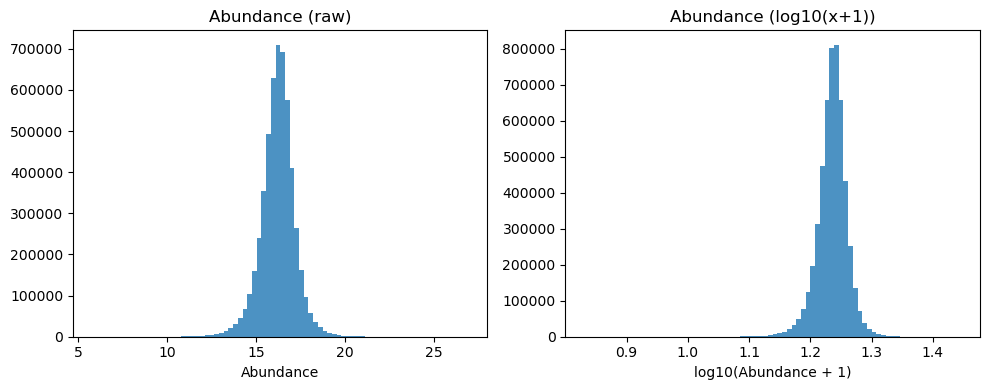

In [5]:
# Distribution of abundances (log-scale)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

vals = df.values.flatten()
vals = vals[~np.isnan(vals)]

axes[0].hist(vals, bins=80, edgecolor="none", alpha=0.8)
axes[0].set_title("Abundance (raw)")
axes[0].set_xlabel("Abundance")

axes[1].hist(np.log10(vals + 1), bins=80, edgecolor="none", alpha=0.8)
axes[1].set_title("Abundance (log10(x+1))")
axes[1].set_xlabel("log10(Abundance + 1)")
plt.tight_layout()
plt.show()

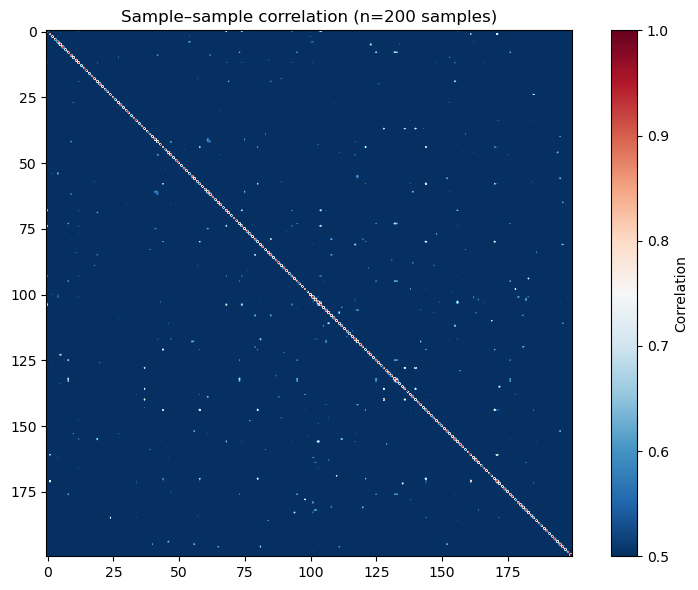

In [6]:
# Sample correlation (subsample columns for speed if needed)
n_samp = min(200, df.shape[1])
sub = df.sample(n=n_samp, axis=1, random_state=42)
corr = sub.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=0.5, vmax=1)
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_title(f"Sample–sample correlation (n={n_samp} samples)")
plt.tight_layout()
plt.show()

In [7]:
# Top variable genes (by variance or CV)
gene_var = df.var(axis=1)
gene_mean = df.mean(axis=1)
gene_cv = np.sqrt(gene_var) / (gene_mean + 1e-10)

top_var = gene_var.nlargest(20)
print("Top 20 genes by variance:")
print(top_var)

Top 20 genes by variance:
GeneSymbol
RGS22               17.025832
RNF17               14.007047
NBPF10              10.775817
ZNF675              10.706302
OTUD6A              10.678288
HFM1                 8.946814
COL21A1              8.415507
DLX2                 8.382313
COL9A1               7.976141
ZBBX                 7.863192
TTC6                 7.655465
ZNF799               7.484706
FNIP2                7.388767
XAGE2                7.240637
NP_001289738         7.036003
CARTPT               6.841080
XXX_NP_001155        6.737787
KCTD7                6.676348
XXX_NP_001018082     6.661403
ZNF677               6.533858
dtype: float64
